In [3]:
import os

os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# os.environ["HF_HOME"] = "/mnt/data/yizhenyu/hf_cache"
# os.environ["HUGGINGFACE_HUB_CACHE"] = os.path.join(os.environ["HF_HOME"], "hub")
# os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.environ["HF_HOME"], "transformers")
# os.environ["HF_HUB_OFFLINE"] = "1"
# os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [4]:
import argparse
import datetime
import json
import numpy as np

import time
from pathlib import Path
import time
import torch

import timm
import open_clip

import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import sys

PROJECT_ROOT = "/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import util.misc as misc
from util.misc import NativeScalerWithGradNormCount as NativeScaler
from util.misc import add_weight_decay

from dataset.dataset_endoscopy_bs_mul import EndoscopyDataset, get_train_loader_distributed
from v3_models_mae_clip_MuImg_FG import MaskedAutoencoder_MuImg_ViT as EndoVLP
from v2_models_mae_clip_MuImg import MaskedAutoencoder_MuImg_ViT as MAE_or_CLIP
# from v4_models_mae_clip_MuImg_FG_dinov3 import MaskedAutoencoder_MuImg_ViT as EndoVLP_dinov3
from v5_models_mae_clip_MuImg_FG_dinov3_biomedclipText import MaskedAutoencoder_MuImg_ViT as EndoVLP_dinov3_biomedclipText


/mnt/data/xujianwei.xjw/conda_envs/ms-swift/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [82]:
# In Jupyter: build args with explicit values for ALL arguments in your parser
from main_pretrain_v1 import get_args_parser
parser = get_args_parser()
args = parser.parse_args([
    # Mode
    "--mode", "endovlp",               # endovlp | clip | mae
    # "--mode", "clip",  
    # Model
    "--model", "vit_base_patch16",
    '--vit_pretrain', 'dinov3',
    "--input_size", "224",
    '--train_from_scratch',

    "--embed_dim", "768",
    "--depth", "12",
    "--num_heads", "12",
    "--decoder_embed_dim", "512",
    "--decoder_depth", "8",
    "--decoder_num_heads", "16",
    "--pooing_topk", "3",

    "--max_imgs", "150"
])

In [83]:
# define the model
from v5_models_mae_clip_MuImg_FG_dinov3_biomedclipText import build_M2GCLIP
# from v6_models_mae_clip_MuImg_FG_dinov3_biomedclipText_UniLatent import build_M2GCLIP
print(f"Creating model: {args.mode}, {args.model}")
if args.mode == 'endovlp':
    if args.vit_pretrain == 'clip':
        raw_model = EndoVLP(
            img_size=args.input_size,
            embed_dim=args.embed_dim, depth=args.depth, num_heads=args.num_heads,
            decoder_embed_dim=args.decoder_embed_dim, decoder_depth=args.decoder_depth, 
            decoder_num_heads=args.decoder_num_heads,
            norm_pix_loss=args.norm_pix_loss, vit_pretrain=args.vit_pretrain,
        )
    elif args.vit_pretrain == 'dinov3':
        raw_model = build_M2GCLIP(model_type=args.model, args=args)

elif args.mode in ['mae', 'clip']:
    raw_model = MAE_or_CLIP(
        img_size=args.input_size,
        embed_dim=args.embed_dim, depth=args.depth, num_heads=args.num_heads,
        decoder_embed_dim=args.decoder_embed_dim, decoder_depth=args.decoder_depth, 
        decoder_num_heads=args.decoder_num_heads,
        norm_pix_loss=args.norm_pix_loss,
        mode = args.mode,
        vit_pretrain = args.vit_pretrain
    )

Creating model: endovlp, vit_base_patch16


In [84]:
class EndoRetrievalModel(nn.Module):
    def __init__(self, model_instance, mode='endovlp'):
        super().__init__()
        self.model = model_instance # 你的原始模型实例
        self.mode = mode

    def get_local_image_features(self, imgs):
        """提取本地视觉特征"""
        #[1,3,H,W]
        # 1. 经过 Encoder
        latent, _, _ = self.model.forward_encoder(imgs, 0.0)
        
        # 2. 获取 CLS 和 Patch 均值
        cls_tokens = latent[:, 0]
        # 假设 n_storage_tokens 存在于 encoder 中
        if self.mode == 'endovlp':
            patch_tokens = latent[:, 1 + self.model.encoder.n_storage_tokens:] 
        elif self.mode == 'clip':
            patch_tokens = latent[:, 1:]
        # 3. 投影到对齐空间
        visual_feature = self.model.image_feat_projection(
            torch.cat([cls_tokens, patch_tokens.mean(dim=1)], dim=1)
        )
        if self.mode == 'endovlp':
            visual_feature = self.model.image_projection_fg(visual_feature)
            # visual_feature = self.model.image_projection(visual_feature) 
        elif self.mode == 'clip':
            visual_feature = self.model.image_projection(visual_feature)
        return F.normalize(visual_feature, p=2, dim=-1)

    def get_global_image_features(self, imgs):
        """提取并聚合多图视觉特征"""
        # [T,3,H,W]
        # 1. 经过 Encoder
        latent, _, _ = self.model.forward_encoder(imgs, 0.0)
        
        # 2. 获取 CLS 和 Patch 均值
        cls_tokens = latent[:, 0]
        # 假设 n_storage_tokens 存在于 encoder 中
        patch_tokens = latent[:, 1 + self.model.encoder.n_storage_tokens:] 
        
        # 3. 投影到对齐空间
        per_visual_features = self.model.image_feat_projection(
            torch.cat([cls_tokens, patch_tokens.mean(dim=1)], dim=1)
        )
        
        # 4. 聚合 (Packed Mean Pooling)
        global_visual_features = self.model.packed_mean_pooling(per_visual_features, [len(imgs)])
        global_visual_features = self.model.image_projection(global_visual_features)
        # 5. 归一化用于检索
        return F.normalize(global_visual_features, p=2, dim=-1)

    def get_text_features(self, texts):
        """提取文本特征"""
        # 对应你 forward 中的 forward_text
        if self.mode == 'endovlp':
            text_features = self.model.forward_text(texts)
        elif self.mode == 'clip':
            text_features = self.model.forward_text(texts) @ self.model.text_projection
        return F.normalize(text_features, p=2, dim=-1)

In [233]:
if args.mode == 'endovlp':
  # ckpt_path = '/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/output_dir_endovlp_new/vitb16_topk3_pretrainedfromdinov3_biomedtext/training_365306/checkpoint-4.pth'
  # ckpt_path = '/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/output_dir_endovlp_new_unilatent/vitb16_topk3_dinov3_biomedtext/training_369036/checkpoint-2.pth'
  ckpt_path = '/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/output_dir_endovlp_new/vitb16_topk3_pretrainedfromdinov3_biomedtext/training_365306/checkpoint-10.pth'
elif args.mode == 'clip':
  # ckpt_path = '/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/output_dir_clip/2026-02-05-06_25_39/checkpoint-3.pth'
  ckpt_path = '/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/output_dir_clip/2026-02-08-03_31_28/checkpoint-13.pth'

raw_model.load_state_dict(torch.load(ckpt_path, weights_only=False)['model'])
model = EndoRetrievalModel(raw_model, mode=args.mode).cuda()
model.eval()
print('done')

done


In [192]:
testsize = args.input_size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if args.mode == 'clip':
    tokenizer = open_clip.get_tokenizer('ViT-B-16')
else:
    # tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
    tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",
    # cache_dir=os.path.expanduser('~/.cache/huggingface/hub')
    )
# %%
def get_transform(testsize=224):
    return transforms.Compose([
        transforms.Resize((testsize, testsize)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

def process_data(image_groups, text_list, transform, tokenizer):
    """
    Args:
        image_groups: List[List[str]], 每个子列表是一个样本的多张图路径
        text_list: List[str], 每个样本对应的全局描述文本
    """
    all_imgs = []
    image_counts = []
    
    # 处理图片
    for group in image_groups:
        group_imgs = []
        for p in group:
            if isinstance(p, str):
                try:
                    img = Image.open(p).convert('RGB')
                except Exception as e:
                    # print(f"Error loading image {p}: {e}")
                    continue
            else:
                img = p
            group_imgs.append(transform(img))
        all_imgs.append(torch.stack(group_imgs))
        image_counts.append(len(group))
    
    # imgs_tensor = torch.stack(all_imgs)
    
    # 处理文本 (Full Text)
    texts_tokenized = tokenizer(text_list)
    
    return all_imgs, texts_tokenized, image_counts

transform = get_transform(testsize)

In [11]:
# # %%
# import matplotlib.pyplot as plt
# import seaborn as sns

# def visualize_similarity(similarity_matrix, image_labels, text_labels, title="Image-Text Retrieval Similarity"):
#     """
#     Args:
#         similarity_matrix: torch.Tensor 或 np.array, 形状为 [N, M]
#         image_labels: 纵轴标签 (例如: ['Sample 1', 'Sample 2', ...])
#         text_labels: 横轴标签 (例如: ['Cecum', 'Pylorus', ...])
#     """
#     # 如果是 Tensor，转为 numpy
#     if torch.is_tensor(similarity_matrix):
#         sim_np = similarity_matrix.cpu().detach().numpy()
#     else:
#         sim_np = similarity_matrix

#     # --- 可选：对相似度进行归一化，使差异更明显 ---
#     # 使用 softmax 或者简单的 min-mmax 缩放，以便于观察颜色对比
#     sim_np = np.exp(sim_np * 1) / np.sum(np.exp(sim_np * 1), axis=1, keepdims=True) 
#     sim_np = sim_np.transpose(1, 0)
#     plt.figure(figsize=(4+sim_np.shape[1]*2, sim_np.shape[0]*2))
#     # plt.figure(figsize=(12,8))
    
#     # 绘制热力图
#     # cmap 可选 'Blues', 'viridis', 'magma', 'Rocket'
#     ax = sns.heatmap(sim_np, 
#                 xticklabels=image_labels, 
#                 yticklabels=text_labels, 
#                 annot=True,       # 在格子里显示数值
#                 fmt=".2f",        # 数值格式
#                 cmap='viridis',     # 颜色地图
#                 # --- A: 格子内数字的大小 ---
#                 annot_kws={"size": 20, "weight": "bold"}, 
                
#                 cbar_kws={'label': 'Similarity Score'})

#     plt.title(title, fontsize=15)
#     plt.xlabel("Anatomical Sites (Text Prompts)", fontsize=12)
#     plt.ylabel("Test Image Samples", fontsize=12)
#     ax.tick_params(axis='x', labelsize=20) # X轴刻度文字大小
#     ax.tick_params(axis='y', labelsize=20) # Y轴刻度文字大小  
    
#     # 旋转横坐标标签，防止重叠
#     plt.xticks(rotation=45, ha='right')
#     plt.yticks(rotation=0)
    
#     plt.tight_layout()
#     plt.show()


In [12]:
# # %%
# import matplotlib.pyplot as plt
# import seaborn as sns
# import torch
# import numpy as np
# from sklearn.metrics import accuracy_score, roc_auc_score
# from sklearn.preprocessing import LabelBinarizer

# def visualize_similarity_with_metrics(similarity_matrix, image_labels, text_labels, title="Endoscopy Site Retrieval Evaluation"):
#     """
#     Args:
#         similarity_matrix: [N_samples, M_classes] 图像与文本的原始相似度得分
#         image_labels: 长度为 N 的列表，包含每张图的真实标签字符串 (e.g. ['cecum', 'z-line', ...])
#         text_labels: 长度为 M 的列表，包含所有候选类别的名称
#     """
#     # 1. 数据转换
#     if torch.is_tensor(similarity_matrix):
#         sim_np = similarity_matrix.cpu().detach().numpy()
#     else:
#         sim_np = similarity_matrix
#     # 2. 计算概率分布 (Softmax) 用于评估指标
#     # 建议乘以一个温度系数（如 10），使分布更显著
#     # print(np.max(sim_np))
#     if np.max(sim_np) > 100:
#         print("WARNING: similarity matrix contains values > 10")
#         sim_np = sim_np / np.max(sim_np)
#     probs = np.exp(sim_np * 1) / np.sum(np.exp(sim_np * 1), axis=1, keepdims=True)
    
#     # 3. 计算指标 (ACC & AUC)
#     # 将字符串标签转换为索引数字
#     label_to_idx = {name: i for i, name in enumerate(text_labels)}
#     y_true = np.array([label_to_idx[l] for l in image_labels])
#     y_pred = np.argmax(probs, axis=1)
    
#     # --- ACC ---
#     acc = accuracy_score(y_true, y_pred)
    
#     # --- AUC ---
#     try:
#         # 使用 LabelBinarizer 处理多分类 AUC
#         lb = LabelBinarizer()
#         lb.fit(range(len(text_labels)))
#         y_true_bin = lb.transform(y_true)
        
#         # 如果只有两个类，roc_auc_score 逻辑略有不同
#         if len(text_labels) == 2:
#             auc = roc_auc_score(y_true, probs[:, 1])
#         else:
#             # multi_class='ovr' (One-vs-Rest) 适合不平衡或一般的多分类任务
#             auc = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')
#         metrics_str = f"ACC: {acc:.4f}  AUC: {auc:.4f}"
#     except Exception as e:
#         metrics_str = f"ACC: {acc:.4f}  AUC: N/A"
#         auc = 0
#         print(f"AUC calculation failed: {e}")

#     # 4. 可视化 (沿用你的转置逻辑：X轴为图像样本，Y轴为文本标签)
#     if len(image_labels) > 10:
#         print(f"WARNING: too many image labels ({len(image_labels)}), plotting the above 10)")
        
#     plot_data = probs[:10].transpose(1, 0)
    
#     # 动态调整画布大小
#     plt.figure(figsize=(4 + plot_data.shape[1] * 1.5, plot_data.shape[0] * 1.2))
    
#     ax = sns.heatmap(plot_data, 
#                 xticklabels=image_labels[:10], 
#                 yticklabels=text_labels, 
#                 annot=True,       
#                 fmt=".2f",        
#                 cmap='viridis',     
#                 annot_kws={"size": 14, "weight": "bold"}, 
#                 cbar_kws={'label': 'Probability Score'})

#     plt.title(f"{title}\n{metrics_str}", fontsize=18, pad=20)
#     plt.xlabel("Ground Truth Labels (Test Images)", fontsize=14)
#     plt.ylabel("Candidate Site Prompts", fontsize=14)
    
#     ax.tick_params(axis='x', labelsize=14) 
#     ax.tick_params(axis='y', labelsize=14)  
    
#     plt.xticks(rotation=45, ha='right')
#     plt.yticks(rotation=0)
    
#     plt.tight_layout()
#     plt.show()
#     print(f"ACC: {acc:.4f}  AUC: {auc:.4f}")
#     return acc, auc

# # %% [markdown]
# # ### 使用建议：如何获取 image_labels？
# # 既然你是从文件夹随机抽取的，可以通过以下方式直接获取 labels：
# # 
# # # 示例：
# # # sample_image_paths = [['/path/to/cecum/img1.jpg'], ['/path/to/z-line/img2.jpg']]
# # # image_labels = [os.path.basename(os.path.dirname(p[0])) for p in sample_image_paths]
# # # visualize_similarity_with_metrics(similarity_matrix, image_labels, text_labels)


In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.preprocessing import LabelBinarizer
import random

def visualize_similarity_with_metrics(similarity_matrix, image_labels, text_labels, title="Endoscopy Site Retrieval Evaluation"):
    """
    Args:
        similarity_matrix: [N_samples, M_classes] 图像与文本的原始相似度得分
        image_labels: 长度为 N 的列表，包含每张图的真实标签字符串
        text_labels: 长度为 M 的列表，包含所有候选类别的名称
    """
    # 1. 数据转换与概率计算
    if torch.is_tensor(similarity_matrix):
        sim_np = similarity_matrix.cpu().detach().numpy()
    else:
        sim_np = similarity_matrix

    # 简单归一化防止指数溢出
    if np.max(sim_np) > 50:
        sim_np = sim_np / (np.max(sim_np) / 10.0)
    
    # 计算 Softmax 概率
    exp_sim = np.exp(sim_np)
    probs = exp_sim / np.sum(exp_sim, axis=1, keepdims=True)
    
    # 标签转索引
    label_to_idx = {name: i for i, name in enumerate(text_labels)}
    y_true = np.array([label_to_idx[l] for l in image_labels])
    y_pred = np.argmax(probs, axis=1)
    
    # 2. 计算全局指标
    acc_global = accuracy_score(y_true, y_pred)
    lb = LabelBinarizer()
    lb.fit(range(len(text_labels)))
    y_true_bin = lb.transform(y_true)
    
    try:
        auc_global = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')
    except:
        auc_global = 0.0

    # 3. 计算每个类别的 ACC (Recall) 和 AUC
    per_class_metrics = {}
    print("\n" + "="*50)
    print(f"{'Class Name':<20} | {'ACC (Recall)':<12} | {'AUC (OvR)':<10}")
    print("-" * 50)
    
    for i, class_name in enumerate(text_labels):
        # 该类的真实掩码
        idx = (y_true == i)
        
        # 计算该类 ACC (即 Recall: 该类对的占该类总数的比例)
        if np.sum(idx) > 0:
            # 只有在样本中存在该类时才计算
            cls_acc = recall_score(y_true == i, y_pred == i, zero_division=0)
            
            # 计算该类 AUC (One-vs-Rest)
            try:
                cls_auc = roc_auc_score(y_true_bin[:, i], probs[:, i])
            except:
                cls_auc = 0.0
        else:
            cls_acc, cls_auc = 0.0, 0.0
            
        per_class_metrics[class_name] = {"acc": cls_acc, "auc": cls_auc}
        print(f"{class_name:<20} | {cls_acc:<12.4f} | {cls_auc:<10.4f}")
    name_total = 'total'
    print(f"{name_total:<20} | {acc_global:<12.4f} | {auc_global:<10.4f}")
    print("="*50)

    # 4. 随机选取 10 个例子进行可视化
    num_samples = len(image_labels)
    display_num = min(10, num_samples)
    # 随机采样索引
    random_indices = np.random.choice(range(num_samples), display_num, replace=False)
    
    # 提取采样数据
    selected_probs = probs[random_indices]
    selected_labels = [image_labels[i] for i in random_indices]
    
    # 转置用于绘图：Y轴为文本类别，X轴为随机选取的图像样本
    plot_data = selected_probs.transpose(1, 0)
    
    # 5. 绘图
    plt.figure(figsize=(max(8, display_num * 1.5), len(text_labels) * 1.0))
    
    metrics_str = f"Global ACC: {acc_global:.4f}  Global AUC: {auc_global:.4f}"
    
    ax = sns.heatmap(plot_data, 
                xticklabels=selected_labels, 
                yticklabels=text_labels, 
                annot=True,       
                fmt=".2f",        
                cmap='viridis',     
                annot_kws={"size": 12, "weight": "bold"}, 
                cbar_kws={'label': 'Probability Score'})

    plt.title(f"{title}\n{metrics_str}\n(Randomly sampled {display_num} examples)", fontsize=16, pad=20)
    plt.xlabel("Ground Truth Labels (Sampled Images)", fontsize=12)
    plt.ylabel("Candidate Site Prompts", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    return acc_global, auc_global, per_class_metrics


In [13]:
import os
import random
from pathlib import Path
base_dir = '/mnt/data/yizhenyu/data/Endomaster/dataset/hyper_kvasir/hyper-kvasir/labeled-images/'

def get_random_endoscopy_samples(base_path, num_per_class=2, mode='both', seed=None, get_all=False):
    """
    从内镜文件夹中随机选取图片路径，支持按消化道区域过滤。
    
    Args:
        base_path: Hyper-Kvasir 标注图像的根目录 ('.../labeled-images/')
        num_per_class: 每个解剖部位随机抽取的图片数量
        mode: 'upper' (仅上), 'lower' (仅下), 'both' (全部)
        seed: 随机种子
    
    Returns:
        sample_image_paths: List[List[str]], 例如 [['path1'], ['path2'], ...]
    """
    if seed is not None:
        random.seed(seed)
        
    # 定义完整结构
    structure = {
        "lower-gi-tract": ["cecum", "ileum", "retroflex-rectum"],
        "upper-gi-tract": ["pylorus", "retroflex-stomach", "z-line"]
    }
    
    # 根据 mode 确定要遍历的 tract
    if mode == 'upper':
        tracts_to_process = ["upper-gi-tract"]
    elif mode == 'lower':
        tracts_to_process = ["lower-gi-tract"]
    elif mode == 'both':
        tracts_to_process = ["lower-gi-tract", "upper-gi-tract"]
    else:
        raise ValueError("mode 参数必须是 'upper', 'lower' 或 'both'")
    
    all_selected_paths = []
    
    for tract in tracts_to_process:
        categories = structure[tract]
        for cat in categories:
            # 构建完整路径
            cat_dir = Path(base_path) / tract / "anatomical-landmarks" / cat
            
            if not cat_dir.exists():
                print(f"跳过：文件夹不存在 {cat_dir}")
                continue
            
            # 查找 jpg 和 jpeg 图片
            images = list(cat_dir.glob("*.jpg")) + list(cat_dir.glob("*.jpeg"))
            
            if not images:
                print(f"警告: 类别 '{cat}' 下没有找到图片")
                continue
                
            # 随机采样数量控制
            if get_all:
                selected = images
            else:
                actual_num = min(len(images), num_per_class)
                selected = random.sample(images, actual_num)
            
            # 封装为 [[path1], [path2], ...]
            for img_path in selected:
                all_selected_paths.append([str(img_path)])
    
    # 随机打乱列表顺序，避免同类图片连续排列
    random.shuffle(all_selected_paths)
    
    print(f"已从 {mode} 消化道路径中选取了 {len(all_selected_paths)} 个样本。")
    return all_selected_paths

In [50]:
# in retroflexion mode.
# site_prompts_dict = {
#     "ileum": "An image of the terminal ileum.",
#     "cecum": "An image of the cecum.",
#     "retroflex-rectum": "An image of rectum",
# }

# 强调判别性标志物
# site_prompts_dict = {
#     "cecum": (
#         "This is a colonoscopy report. Insertion: The colonoscope was advanced smoothly to the cecum. "
#         "The appendiceal orifice and the tri-radiate confluence of the colonic bands (crow's foot appearance) are clearly visible."
#     ),
#     "ileum": "An image of the terminal ileum.",
#     "retroflexion-rectum": (
#         "This is a colonoscopy report. Rectum in retroflexion: The black shaft of the endoscope is visible, "
#         "performing a U-turn to observe the rectal cardia and anal verge."
#     )
# }

site_prompts_dict = text_prompts = {
    "ileum": "An endoscopy image of the terminal ileum showing small bowel mucosa with villi and lymphoid follicles.",
    "cecum": "An endoscopy image of the cecum showing the appendiceal orifice and the tri-radiate fold of the cecum.",
    "retroflex-rectum": "An image of rectum",
}

# site_prompts_dict = {
#     "ileum": "An endoscopy image of the terminal ileum showing small bowel mucosa with villi and lymphoid follicles.",
#     "cecum": "An endoscopy image of the cecum showing the appendiceal orifice and the tri-radiate fold of the cecum.",
#     "retroflex-rectum": "An endoscopy image of the rectum in retroflexion maneuver, showing the endoscope shaft and the rectal vault near the anal canal."
# }

class_names_lower = [k for k in site_prompts_dict]
site_prompts_lower = [site_prompts_dict[k] for k in site_prompts_dict]
sample_image_lower = get_random_endoscopy_samples(base_dir, num_per_class=3, mode='lower', seed=42, get_all=True)

已从 lower 消化道路径中选取了 1409 个样本。


1409it [00:28, 50.19it/s]



Class Name           | ACC (Recall) | AUC (OvR) 
--------------------------------------------------
ileum                | 0.8889       | 0.5947    
cecum                | 0.0000       | 0.2445    
retroflex-rectum     | 0.4450       | 0.7441    
total                | 0.1292       | 0.5278    


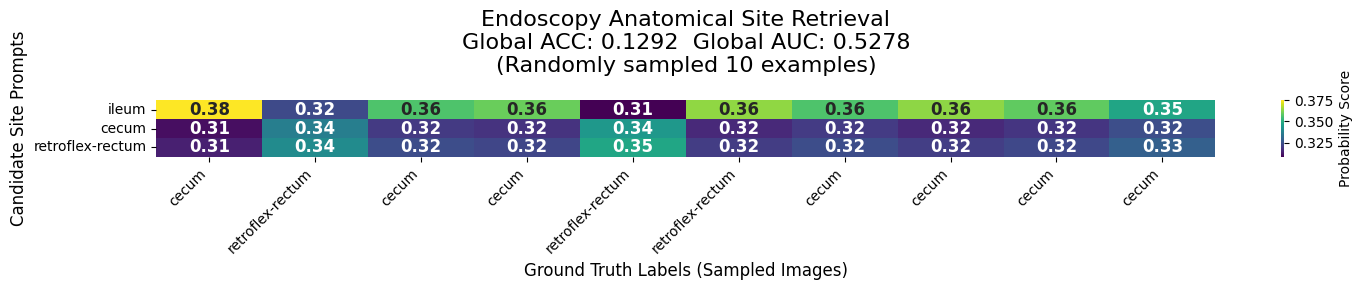

In [51]:
from tqdm import tqdm
sample_texts = site_prompts_lower
sample_image_paths = sample_image_lower
class_names = class_names_lower
imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)
image_features_all, sample_names = [], []
for imgs, img_count, paths in tqdm(zip(imgs_batch, img_counts, sample_image_paths)):
  with torch.no_grad():
    if img_count == 1:
      image_features = model.get_local_image_features(imgs.cuda())
    elif img_count > 1:
      image_features = model.get_global_image_features(imgs.cuda())
  text_features = model.get_text_features(texts_batch.cuda())
  image_features_all.append(image_features)
  # similarity_matrix[i, j] 表示第 i 个图像样本与第 j 个文本的匹配得分
  similarity_matrix = torch.matmul(image_features, text_features.T) * model.model.logit_scale.exp()
  similarity_matrix = torch.softmax(similarity_matrix, dim=-1).cpu().detach().numpy()
  val, index = np.max(similarity_matrix, axis=-1), np.argmax(similarity_matrix, axis=-1)

  sample_names.append(paths[0].split('/')[-2])

image_features_all = torch.cat(image_features_all, dim=0)
similarity_matrix_all = torch.matmul(image_features_all, text_features.T) * model.model.logit_scale.exp()

res = visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

In [59]:

[float(f"{res[-1][k]['auc']:.4f}") for k in res[-1] ]

[0.5947, 0.2445, 0.7441]

In [234]:
# in retroflexion mode.
site_prompts_dict = {
    "z-line": "An image of z-line",
    "retroflex-stomach": "An image of fundus.",
    "pylorus": "An image of pylorus."
}
# site_prompts_dict = {
#     # 1. Z-line (食管胃交界处)
#     "z-line": "An endoscopy image of the Z-line at the gastroesophageal junction, showing the squamocolumnar junction between esophageal and gastric mucosa.",
    
#     # 2. Retroflex-stomach (胃底倒镜)
#     "retroflex-stomach": "An endoscopy image of the gastric fundus and cardia in retroflexion view, with the endoscope shaft visible in a U-turn maneuver.",
    
#     # 3. Pylorus (幽门)
#     "pylorus": "An endoscopy image of the pyloric sphincter and gastric antrum, showing the circular opening leading to the duodenum.",
# }

class_names_upper = [k for k in site_prompts_dict]
site_prompts_upper = [site_prompts_dict[k] for k in site_prompts_dict]

sample_image_upper = get_random_endoscopy_samples(base_dir, num_per_class=20, mode='upper', seed=42, get_all=True)

已从 upper 消化道路径中选取了 2695 个样本。


2695it [00:58, 46.23it/s]



Class Name           | ACC (Recall) | AUC (OvR) 
--------------------------------------------------
z-line               | 1.0000       | 0.9985    
retroflex-stomach    | 0.8508       | 0.9969    
pylorus              | 0.9720       | 0.9976    
total                | 0.9473       | 0.9977    


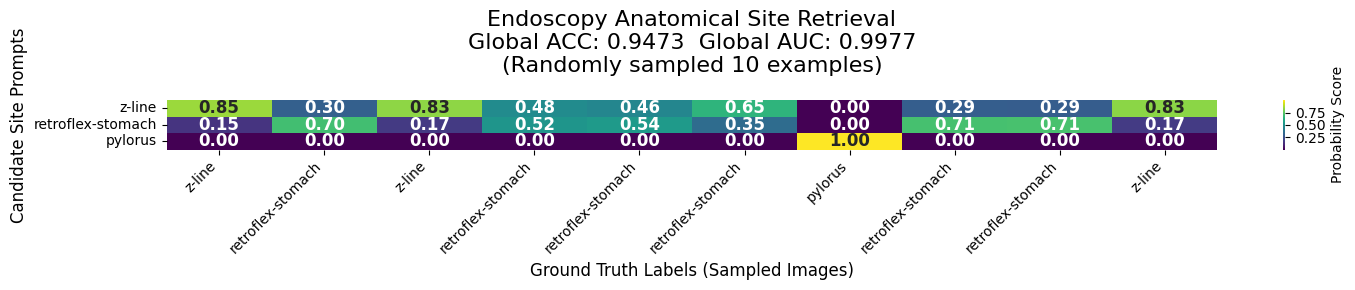

[0.9985, 0.9969, 0.9976]

In [183]:
from tqdm import tqdm
sample_texts = site_prompts_upper
sample_image_paths = sample_image_upper
class_names = class_names_upper
imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)
image_features_all, sample_names = [], []
for imgs, img_count, paths in tqdm(zip(imgs_batch, img_counts, sample_image_paths)):
  with torch.no_grad():
    if img_count == 1:
      image_features = model.get_local_image_features(imgs.cuda())
    elif img_count > 1:
      # image_features = model.get_global_image_features(imgs.cuda())
      image_features = model.get_local_image_features(imgs.cuda())
  text_features = model.get_text_features(texts_batch.cuda())
  image_features_all.append(image_features)
  # similarity_matrix[i, j] 表示第 i 个图像样本与第 j 个文本的匹配得分
  similarity_matrix = torch.matmul(image_features, text_features.T) * model.model.logit_scale.exp()
  similarity_matrix = torch.softmax(similarity_matrix, dim=-1).cpu().detach().numpy()
  val, index = np.max(similarity_matrix, axis=-1), np.argmax(similarity_matrix, axis=-1)

  sample_names.append(paths[0].split('/')[-2])

image_features_all = torch.cat(image_features_all, dim=0)
similarity_matrix_all = torch.matmul(image_features_all, text_features.T) * model.model.logit_scale.exp()

res = visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

[float(f"{res[-1][k]['auc']:.4f}") for k in res[-1] ]

已从 both 消化道路径中选取了 12 个样本。


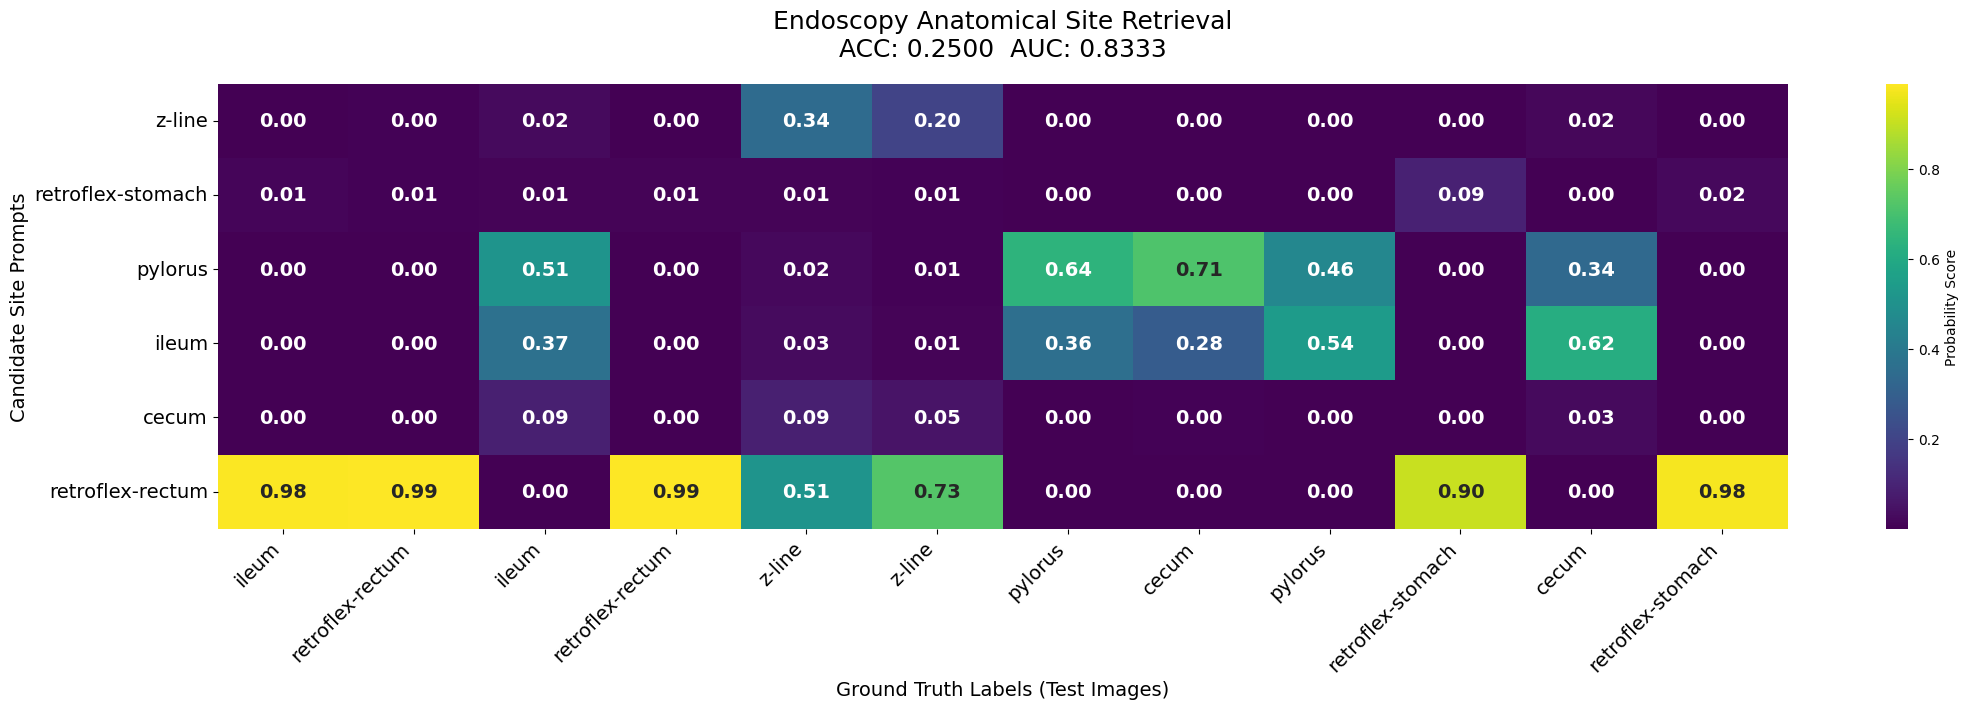

(0.25, 0.8333333333333334)

In [ ]:

# 4. 获取全部
all_samples = get_random_endoscopy_samples(base_dir, num_per_class=2, mode='both', seed=42)
class_names = class_names_upper + class_names_lower
sample_texts = site_prompts_upper + site_prompts_lower

sample_image_paths = all_samples

imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)
image_features_all, sample_names = [], []
for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
  with torch.no_grad():
    if img_count == 1:
      image_features = model.get_local_image_features(imgs.unsqueeze(0).cuda())
    elif img_count > 1:
      image_features = model.get_global_image_features(imgs.cuda())
  text_features = model.get_text_features(texts_batch.cuda())
  image_features_all.append(image_features)
  # similarity_matrix[i, j] 表示第 i 个图像样本与第 j 个文本的匹配得分
  similarity_matrix = torch.matmul(image_features, text_features.T) * model.model.logit_scale.exp()
  similarity_matrix = torch.softmax(similarity_matrix, dim=-1).cpu().detach().numpy()
  val, index = np.max(similarity_matrix, axis=-1), np.argmax(similarity_matrix, axis=-1)

  sample_names.append(paths[0].split('/')[-2])

image_features_all = torch.cat(image_features_all, dim=0)
similarity_matrix_all = torch.matmul(image_features_all, text_features.T) * model.model.logit_scale.exp()

visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

In [ ]:
torch.stack([torch.randn(3,223,223), torch.randn(3,223,223)]).shape

torch.Size([2, 3, 223, 223])

# polypdiag

In [62]:
import cv2
def sample_video_frames(video_path, n_frames, seed=None):
  """
  从视频中采样 n_frames 帧。
  - 若 n_frames <= 总帧数：均匀采样（含首尾）。
  - 若 n_frames > 总帧数：取全部帧 + 随机重复部分帧至 n_frames。

  参数:
    video_path (str): 视频文件路径。
    n_frames (int): 要采样的帧数。
    seed (int, optional): 随机种子，用于可复现性。

  返回:
    List[PIL.Image.Image]: 长度为 n_frames 的图像列表。
  """
  if seed is not None:
    random.seed(seed)
  
  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
    raise IOError(f"无法打开视频文件: {video_path}")
  
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  if total_frames == 0:
    raise ValueError("视频文件帧数为0，可能是损坏或不支持的格式。")
  
  # 读取所有帧（避免多次 set + read，效率更高）
  all_frames = []
  while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    all_frames.append(pil_image)
  
  cap.release()
  
  # 如果实际读取的帧数和 CAP_PROP_FRAME_COUNT 不一致，以实际为准
  actual_total = len(all_frames)
  if actual_total == 0:
    raise ValueError("未能从视频中读取任何帧。")

  if n_frames <= actual_total:
    # 均匀采样（含首尾）
    indices = [int(i * (actual_total - 1) / (n_frames - 1)) for i in range(n_frames)] if n_frames > 1 else [0]
    sampled_frames = [all_frames[i] for i in indices]
  else:
    # 全部帧 + 随机重复
    sampled_frames = all_frames.copy()
    # 随机选择 (n_frames - actual_total) 个帧进行重复
    num_to_repeat = n_frames - actual_total
    repeated = random.choices(all_frames, k=num_to_repeat)  # 可重复采样
    sampled_frames.extend(repeated)
  
  return sampled_frames


In [63]:
import torch

def video_level_prediction(similarity_matrix, k=5):
    """
    Args:
        similarity_matrix: [T, 2] (T是帧数, 2是分类数: 0-polyp, 1-normal)
        k: 取前k个最像息肉的帧
    """
    # 1. 提取息肉类的得分 (假设第0列是polyp)
    polyp_logits = similarity_matrix[:, 0]
    
    # 2. Top-K 聚合逻辑
    # 如果视频帧数小于k，则取全部
    actual_k = min(k, polyp_logits.size(0))
    topk_values, _ = torch.topk(polyp_logits, actual_k)
    
    # 计算 Top-K 的平均得分作为该序列最终的息肉得分
    final_polyp_score = torch.mean(topk_values)
    
    # 3. 阈值判定 (你可以根据实验调整这个阈值，或者直接比较 polyp vs normal)
    # 或者简单对比：
    avg_logits = torch.mean(similarity_matrix, dim=0) # [2]
    
    return final_polyp_score, avg_logits

# 在推理循环中：
# sequence_sims = [] # 存储每一帧的 logits
# ... 得到所有帧的相似度 ...
# seq_sim_tensor = torch.cat(sequence_sims, dim=0) 
# score, _ = video_level_prediction(seq_sim_tensor)


In [64]:
split_file = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/PolypDiag/splits/val.txt'
video_root = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/PolypDiag/videos/'
videos, labels = [], []
with open(split_file, "r") as f:
    for clip_idx, path_label in enumerate(f.read().splitlines()):
        assert (
                len(path_label.split(','))
                == 2
        )
        path, label = path_label.split(',')
        videos.append(os.path.join(video_root, path))
        labels.append(int(label))

sample_image_paths = []
for video_path in videos:
  sample_image_paths.append(sample_video_frames(video_path, n_frames=32))

In [65]:

site_prompts_dict = {
    "normal": "Endoscopic findings of other abnormalities.",
    # "normal": "No polyp.",
    "polyp": "An endoscopic image of a polypoid lesion or mucosal elevation (0.1-0.5cm).",
    # "polyp": "Polyp.",
} # auc: 0.8 with Mean-pooling

# site_prompts_dict = {
#     # 合并了尺寸、形状、表面特征和临床动作
#     "polyp": (
#         "Endoscopic image of a colonic polypoid elevation or small mucosal protrusion (0.3-0.5 cm) "
#         "with a smooth or slightly depressed surface, potentially identified for biopsy forceps removal."
#     ),
    
#     # 合并了正常纹理、萎缩、平坦溃疡以及“非隆起”这一核心特征
#     "non_polyp": (
#         "Endoscopic image showing normal mucosa with clear vascularity, or non-polypoid findings "
#         "such as mucosal atrophy and flat ulcerated areas, with no protruding or raised lesions."
#     )
# }


# site_prompts_dict = {
#     # 描述息肉的视觉特征：凸起、颜色异常、质地
#     "polyp": "An endoscopic image of a colonic polyp, showing a protruding mucosal lesion.",
    
#     # 描述正常的视觉特征：平滑的粘膜、清晰的血管
#     "normal": "Normal colonic mucosa with smooth surface and clear vascular patterns, no lesions.",
# } # auc: 0.6 with Mean-pooling

# site_prompts_dict = {
#     "normal": "Normal and healthy endoscopic mucosa with clear vascular patterns and no signs of lesions.",
#     "polyp": "An endoscopic image of a small polypoid lesion or mucosal elevation (0.3-0.5cm) with a smooth surface.",
#     "other_lesions": "Endoscopic findings of non-polypoid abnormalities, such as flat ulcers, mucosal atrophy, or diffuse inflammation."
# }

class_names = [k for k in site_prompts_dict]
sample_texts = [site_prompts_dict[k] for k in site_prompts_dict]

In [66]:
imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)

In [71]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, f1_score
from tqdm import tqdm

def video_level_prediction(similarity_probs, k=5):
    """
    Args:
        similarity_probs: [T, 2] 经过 softmax 后的概率
        k: 取前 k 帧最像息肉的概率
    Returns:
        final_polyp_score: 视频属于息肉类的得分
    """
    # 假设第 0 列是 polyp
    polyp_probs = similarity_probs[:, 1]
    
    # 取概率最高的 K 帧求平均，作为该视频为“息肉”的置信度
    actual_k = min(k, polyp_probs.shape[0])
    topk_indices = np.argsort(polyp_probs)[-actual_k:]
    final_polyp_score = np.mean(polyp_probs[topk_indices])
    
    return final_polyp_score

# --- 准备容器 ---
all_video_scores = []  # 存储每个视频是 polyp 的概率
all_true_labels = []   # 存储真实标签
K = 1

# 1. 预先提取文本特征 (只需一次)
model.eval()
with torch.no_grad():
    text_features = model.get_text_features(texts_batch.cuda())
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# 2. 遍历视频样本
# 注意：假设你的 labels 对应：1-Polyp, 0-Normal
for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
    with torch.no_grad():
        # 提取图像特征并归一化
        image_features = model.get_local_image_features(imgs.cuda())
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        # 计算原始相似度 (Logits)
        logit_scale = model.model.logit_scale.exp()
        logits = (image_features @ text_features.T) * logit_scale
        
        # 转换为概率 [T, 2]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        
        # 视频级聚合：得到该视频是 Polyp 的综合得分
        video_polyp_score = video_level_prediction(probs, k=K)
        
        all_video_scores.append(video_polyp_score)
        all_true_labels.append(label)


80it [00:05, 13.54it/s]


In [72]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, f1_score
y_scores = np.array(all_video_scores)
y_true = np.array(all_true_labels) # 1-Polyp, 0-Normal

y_true_binary = np.where(y_true == 1, 1, 0) 
f1_best, thres_best = 0, 0
for thres in np.arange(0.1, 1.0, 0.01):
  y_pred = (y_scores > thres).astype(int)

  f1 = f1_score(y_true_binary, y_pred)
  if f1 > f1_best:
    f1_best = f1
    thres_best = thres
    auc = roc_auc_score(y_true_binary, y_scores)
    acc = accuracy_score(y_true_binary, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred).ravel()
    sen = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity / Recall
    spe = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    pre = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision

print(f"=== Threshold: {thres_best:.2f} ===")
print(f"=== Video-Level Evaluation (N={len(y_true)}, K={K}) ===")
print(f"AUC: {auc:.4f}")
print(f"ACC: {acc:.4f}")
print(f"SEN (Sensitivity/Recall): {sen:.4f}")
print(f"SPE (Specificity): {spe:.4f}")
print(f"PRE (Precision): {pre:.4f}")
print(f"F1: {f1_best:.4f}")


=== Threshold: 0.10 ===
=== Video-Level Evaluation (N=80, K=1) ===
AUC: 0.2692
ACC: 0.3750
SEN (Sensitivity/Recall): 0.3333
SPE (Specificity): 0.5000
PRE (Precision): 0.6667
F1: 0.4444


# LIMUC

In [87]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

def compute_single_card_metrics(all_scores, all_true_labels, num_classes=2):
    """
    针对单卡测试结果计算指标
    
    Args:
        all_scores: [N, C] 的 Tensor 或 array，表示 Softmax 后的概率 (0~1)
        all_true_labels: [N] 的 Tensor 或 array，表示真实标签索引 (0, 1, ...)
        num_classes: 类别总数 (二分类为 2, MES 为 4)
        
    Returns:
        acc, prec, rec, spe, auc
    """
    # 1. 统一转换为 numpy 格式
    if torch.is_tensor(all_scores):
        all_probs = all_scores.cpu().detach().numpy()
    else:
        all_probs = all_scores
        
    if torch.is_tensor(all_true_labels):
        all_targets = all_true_labels.cpu().detach().numpy()
    else:
        all_targets = all_true_labels

    # 2. 获取预测索引 [N]
    all_preds = np.argmax(all_probs, axis=1)

    # 3. 计算 Accuracy (准确率)
    acc = accuracy_score(all_targets, all_preds)
    
    # 4. 计算 Precision (精确率) 和 Recall (召回率/敏感度)
    # 对于二分类，常用 'binary'；对于多分类，使用 'macro'
    avg_mode = 'binary' if num_classes == 2 else 'macro'
    prec = precision_score(all_targets, all_preds, average=avg_mode, zero_division=0)
    rec = recall_score(all_targets, all_preds, average=avg_mode, zero_division=0)
    
    # 5. 计算 AUC (曲线下面积)
    try:
        if num_classes == 2:
            # 二分类时，通常取正类（索引1）的得分
            # 如果你的正类是 0 (Polyp)，则需传入 all_probs[:, 0] 并反转 labels
            auc = roc_auc_score(all_targets, all_probs[:, 1])
        else:
            # 多分类使用 One-vs-One 策略
            auc = roc_auc_score(all_targets, all_probs, multi_class='ovo', average='macro')
    except Exception as e:
        print(f"AUC 计算失败: {e}")
        auc = 0.0

    # 6. 计算 Specificity (特异度)
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))
    if num_classes == 2:
        # 二分类逻辑: TN / (TN + FP)
        # 注意：这里假设 0 是负类(Normal)，1 是正类(Polyp/Disease)
        tn, fp, fn, tp = cm.ravel()
        spe = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        # 多分类逻辑: 计算每一类作为负例时的特异度再取均值 (参考你提供的代码)
        spec_list = []
        for i in range(num_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
            spec_list.append(specificity_i)
        spe = np.mean(spec_list)

    return acc, prec, rec, spe, auc


In [88]:
limuc_root = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/LIMUC/test_set'
classes = ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']
images, labels = [], []
for folder in classes:
  folder_path = os.path.join(limuc_root, folder)
  for file_name in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file_name)
    images.append(file_path)
    labels.append(int(folder.split(' ')[-1]))
random.shuffle(images)
labels = [int(x.split('/')[-2].split(' ')[-1]) for x in images]

# combined = list(zip(images, labels))
# shuffled = np.random.permutation(combined)
# sample_image_paths, labels = zip(*shuffled)

sample_image_paths = [[x] for x in images]

In [75]:
imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)

In [89]:
print(len(imgs_batch), sum(img_counts))

1686 1686


In [90]:

mes_prompts_dict = {
    # Grade 0: 正常或静止期
    "MES_0": (
        "Mayo Endoscopic Score 0: Normal or inactive ulcerative colitis. "
        "The mucosa shows a clear and distinct vascular pattern, smooth surface, and no signs of inflammation."
    ),
    
    # Grade 1: 轻度 (血管纹理模糊、红斑)
    "MES_1": (
        "Mayo Endoscopic Score 1: Mild ulcerative colitis activity. "
        "Characterized by erythema (redness) and a decreased vascular pattern. "
        "The mucosa looks blurred but has no spontaneous bleeding."
    ),
    
    # Grade 2: 中度 (血管纹理消失、糜烂、脆性增加)
    "MES_2": (
        "Mayo Endoscopic Score 2: Moderate ulcerative colitis activity. "
        "Marked erythema with a completely absent vascular pattern. "
        "Presence of mucosal friability (bleeds when touched) and small erosions."
    ),
    
    # Grade 3: 重度 (自发出血、大溃疡)
    "MES_3": (
        "Mayo Endoscopic Score 3: Severe ulcerative colitis activity. "
        "Prominent ulcerations and spontaneous bleeding are visible. "
        "The mucosal surface is heavily damaged with significant inflammatory exudate."
    )
}

# mes_prompts_dict = {
#     # Grade 0: 正常或静止期
#     # 模仿语料中 Esophagus/Cardia 的描述：smooth and soft, clear vascular pattern
#     "MES_0": (
#         "Mucosa: The mucosa is smooth and soft, with a clear and distinct vascular pattern. "
#         "No congestion, edema, or erosions are observed. The vascular network is clearly visible."
#     ),
    
#     # Grade 1: 轻度
#     # 模仿语料中 Body/Antrum 的描述：mixed red and white, predominantly white, congestion
#     "MES_1": (
#         "Mucosa: The mucosa shows a mixed red and white appearance, predominantly red, with mild mucosal congestion. "
#         "The vascular pattern is blurred or faintly visible; no superficial erosions or bleeding observed."
#     ),
    
#     # Grade 2: 中度
#     # 模仿语料中 Antrum 异常项：mosaic of red and white, predominantly red, scattered superficial erosions
#     "MES_2": (
#         "This is a colonoscopy report. "
#         "Mucosa: The mucosa exhibits a mosaic of red and white areas, predominantly white, with significant mucosal hyperemia. "
#         "Vascular markings are completely absent. Scattered superficial erosions and mucosal friability are noted."
#     ),
    
#     # Grade 3: 重度
#     # 模仿语料中严重异常描述：predominantly red, ulcers, bleeding
#     "MES_3": (
#         "This is a colonoscopy report. "
#         "Mucosa: The mucosa is predominantly red and glistening, showing prominent ulcerations and spontaneous bleeding. "
#         "Inflammatory exudates are present, and the normal mucosal architecture is significantly damaged."
#     )
# }


# mes_prompts_dict = {
#     # 合并 MES 0 与 1：侧重于“血管纹理可见”和“无溃疡”
#     # 关键词：clear/faintly visible vascular pattern, predominantly white, no ulcers
#     "Remission_Mild (MES 0-1)": (
#         "Mucosa: The mucosa is smooth and soft, with the vascular pattern clear or faintly visible. "
#         "Appearance is predominantly red, with mild mucosal congestion. "
#     ),
    
#     # 合并 MES 2 与 3：侧重于“血管纹理消失”、“明显红斑”和“受损”
#     # 关键词：absent vascular pattern, predominantly red, erosions, ulcers, bleeding
#     "Moderate_Severe (MES 2-3)": (
#         "Mucosa: The mucosa shows predominantly white, with mucosal hyperemia. "
#         "The submucosal vascular network is completely absent. "
#         "Scattered superficial erosions, prominent ulcerations, and spontaneous bleeding are observed."
#     )
# }

# mes_prompts_dict = {
#     # 类别 0: MES 0 (完全正常/缓解)
#     # 模仿语料：smooth and soft, clear vascular pattern, no abnormalities
#     "Normal_Remission (MES 0)": (
#         "Mucosa: The mucosa is smooth and soft, with a clear and distinct vascular pattern. "
#         "The vascular network is sharply visible. No signs of congestion, edema, or erosions. "
#         "No abnormalities observed, and no ulcers or bleeding are present."
#     ),
    
#     # 类别 1: MES 1/2/3 (活动期炎症)
#     # 模仿语料：mosaic of red and white, hyperemia, erosions, ulcers
#     # 涵盖了从血管模糊(1)到消失(2)到出血(3)的所有描述
#     "Active_Inflammation (MES 1-3)": (
#         "Mucosa: The mucosa shows an abnormal mixed red-and-white mottled appearance, "
#         "with mucosal congestion or hyperemia. The vascular pattern is blurred, faintly visible, or completely absent. "
#         "There are findings of scattered superficial erosions, mucosal friability, or prominent ulcerations with bleeding."
#     )
# }


class_names = [k for k in mes_prompts_dict]
sample_texts = [mes_prompts_dict[k] for k in mes_prompts_dict]
texts_batch = tokenizer(sample_texts)

In [91]:

all_video_scores = []  
all_true_labels = []  
K = 100

# 1. 预先提取文本特征 (只需一次)
model.eval()
with torch.no_grad():
    text_features = model.get_text_features(texts_batch.cuda())
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# 2. 遍历视频样本
for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
    with torch.no_grad():
        # 提取图像特征并归一化
        image_features = model.get_local_image_features(imgs.cuda())
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        # 计算原始相似度 (Logits)
        logit_scale = model.model.logit_scale.exp()
        logits = (image_features @ text_features.T) * logit_scale
        
        # 转换为概率 [1, C]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    
        all_video_scores.append(probs.squeeze())

        # label_true = 0 if label <= 1 else 1
        label_true = label
        # label_true = 0 if label <= 0 else 1
        
        all_true_labels.append(label_true)

all_video_scores = np.array(all_video_scores)

1686it [00:15, 105.94it/s]


In [92]:
acc, pre, sen, spe, auc = compute_single_card_metrics(all_video_scores, all_true_labels, num_classes=all_video_scores.shape[1])
print(f"ACC: {acc:.4f}, PRE: {pre:.4f}, SEN: {sen:.4f}, SPE: {spe:.4f}, AUC: {auc:.4f}")


ACC: 0.2752, PRE: 0.2509, SEN: 0.2426, SPE: 0.7516, AUC: 0.4882


In [ ]:
sum([1 if x==0 else 0 for x in all_true_labels]), sum([1 if x==1 else 0 for x in all_true_labels]), sum([1 if x==2 else 0 for x in all_true_labels]), sum([1 if x==3 else 0 for x in all_true_labels])

(925, 464, 177, 120)

# visualize MAE

In [235]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Args:
        tensor: [C, H, W] 
    """
    # 转换为 tensor 并调整形状以便广播 [C, 1, 1]
    mean = torch.tensor(mean).view(-1, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(-1, 1, 1).to(tensor.device)
    
    # 公式: x = z * std + mean
    res = tensor * std + mean
    return res


def unpatchify(x, patch_size=16, channels=3):
    """
    x: (N, L, patch_size**2 * channels)
    imgs: (N, channels, H, W)
    """
    p = patch_size
    h = w = int(x.shape[1]**.5)
    assert h * w == x.shape[1]
    
    x = x.reshape(shape=(x.shape[0], h, w, p, p, channels))
    x = torch.einsum('nhwpqc->nchpwq', x)
    imgs = x.reshape(shape=(x.shape[0], channels, h * p, h * p))
    return imgs

@torch.no_grad()
def visualize_mae_reconstruction(model, img_tensor, mask_ratio=0.75, device="cuda"):
    """
    img_tensor: [1, 3, H, W] - 假设输入是已经 Normalized 过的
    """
    model.to(device)
    model.eval()
    img_tensor = img_tensor.to(device)
    
    # --- 1. 前向传播 ---
    # 调用你 model 里的 encoder 和 decoder
    latent, mask, ids_restore = model.forward_encoder(img_tensor, mask_ratio)
    pred = model.forward_decoder(latent, ids_restore)
    
    # --- 2. 像素反归一化 (针对 MAE 的 norm_pix_loss) ---
    # if getattr(model, 'norm_pix_loss', False):
    target = model.patchify(img_tensor)
    mean = target.mean(dim=-1, keepdim=True)
    var = target.var(dim=-1, keepdim=True)
    pred = pred * (var + 1.e-6)**.5 + mean
        
    # --- 3. 重构图片 (Unpatchify) ---
    reconstructed_img = unpatchify(pred, patch_size=16) # [1, 3, H, W]
    
    # --- 4. 准备带遮罩的图片 ---
    mask_for_vis = mask.detach().unsqueeze(-1).repeat(1, 1, 16**2 * 3)
    mask_for_vis = unpatchify(mask_for_vis, patch_size=16)
    im_masked = img_tensor * (1 - mask_for_vis)
    
    # --- 5. 执行 Denormalize (针对 ImageNet 归一化) ---
    # 我们处理 Batch 中的第一张图 [0]
    img_orig = denormalize(img_tensor[0])
    img_recons = denormalize(reconstructed_img[0])
    img_masked = denormalize(im_masked[0])
    
    # --- 6. 转换为 NumPy 并限制范围在 [0, 1] ---
    def to_np(t):
        t = t.cpu().permute(1, 2, 0).numpy()
        return np.clip(t, 0, 1)

    img_np = to_np(img_orig)
    im_masked_np = to_np(img_masked)
    reconstruction_np = to_np(img_recons)

    # --- 7. 绘图 ---
    plt.figure(figsize=(15, 5))
    titles = ['Original', f'Masked ({int(mask_ratio*100)}%)', 'Reconstruction']
    images = [img_np, im_masked_np, reconstruction_np]
    
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return mask_for_vis


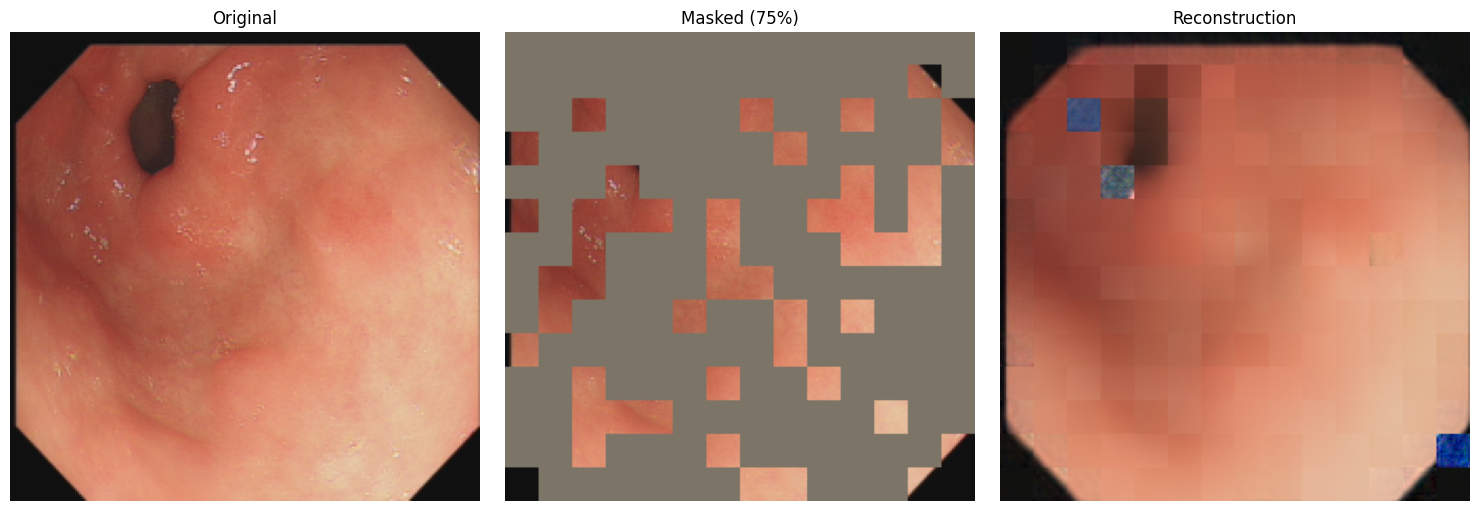

In [236]:
# img_tensor = imgs_batch[2]

import glob
root = '/mnt/data/xujianwei.xjw/endoscopy/ESIMAGE/0011117862--2018-07-23'
paths = glob.glob(os.path.join(root, '*.png'))
path = paths[random.randint(0, len(paths)-1)]
img = Image.open(path).convert("RGB")
img_tensor = transform(img).unsqueeze(0) # 增加 batch 维度

# 3. 调用可视化
mask_for_vis = visualize_mae_reconstruction(model.model, img_tensor, mask_ratio=0.75)

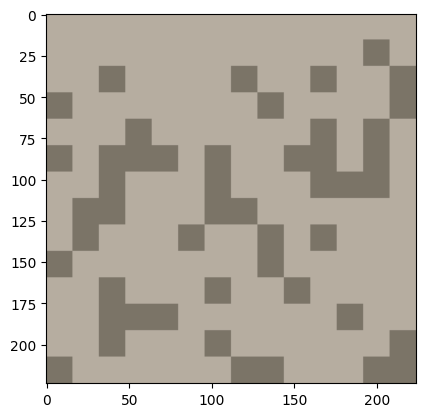

In [244]:
plt.imshow(denormalize(mask_for_vis.cpu()).squeeze().permute(1, 2, 0).numpy())

# Top-k visualization

In [184]:
def read_path_text_from_json():
    """
    Read path and text from json file.
    """
    file_paths = ['/mnt/data/xujianwei.xjw/胃镜/total/dataset/Image_Text_szy_0126_lim7_Final_addValidImageCount.jsonl',
    '/mnt/data/xujianwei.xjw/胃镜/total/dataset/Image_Text_wzzx_0126_lim7_Final_addValidImageCount.jsonl']

    if isinstance(file_paths, str):
        file_paths = [file_paths]
    data_list = []
    for file_path in file_paths:
        assert os.path.exists(file_path), f"file {file_path} not exists"
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    data_list.append(json.loads(line))

    return data_list

data_list = read_path_text_from_json()

In [223]:
idx = random.randint(0, len(data_list)-1)

content = data_list[idx]
folder_path = content['image_path']
parts = folder_path.rstrip('/').split('/')
folder = parts[-2] + '/' + parts[-1]

images = [os.path.join(folder_path, f) for f in os.listdir(folder_path)]

report = content['endo_report']
sub_reports = report.split('\n')[1:]
# sub_reports = ['This is an image of ' + rep.split(':')[0].strip() for rep in sub_reports]
sub_reports_len = len(sub_reports)

abnormal_flags = content['site_abnormality_flags']
normal_flags = [1-x for x in abnormal_flags]
modality = content['modality']

print(idx, folder_path, modality, len(images))

157549 /mnt/data/xujianwei.xjw/endoscopy/tmp_dir/0025285194--2025-01-07--刘吴栋-P1687980 gastroscopy 83


In [224]:
imgs_batch, texts_batch, img_counts = process_data([images], sub_reports, transform, tokenizer)
imgs_batch = imgs_batch[0]
print(sub_reports)

83
['Esophagus: Patent, with smooth mucosa and normal peristalsis. Linear mucosal defects and ulcers noted at the distal esophagus.', 'Cardia: Z-line is clear, mucosa is smooth, and opening/closing function is normal.', 'Fundus: Mucosa shows a mixed red-and-white appearance; yellow mucus lake present in small amount.', 'Body: Mucosa is smooth with a red-and-white appearance, no ulceration or bleeding observed; peristalsis is normal.', 'Angulus: Arch is intact; mucosa appears predominantly white with scattered erosions.', 'Antrum: Mucosa is congested and edematous, with a predominantly white, red-and-white appearance and scattered erosions.', 'Pylorus: Round in shape, opens and closes normally, with smooth mucosa.', 'Duodenum: Normal morphology with healthy mucosal coloration; no ulcers or neoplasms identified. The descending duodenum is patent with no abnormalities.']


In [262]:
with torch.no_grad():
  image_features = model.get_local_image_features(imgs_batch.cuda())
  text_features = model.get_text_features(texts_batch.cuda())
  # similarity_matrix[i, j] 表示第 i 个图像样本与第 j 个文本的匹配得分
  similarity_matrix_raw = torch.matmul(image_features, text_features.T) * model.model.logit_scale.exp()
  similarity_matrix = torch.softmax(similarity_matrix_raw, dim=0).cpu().detach().numpy() # [N, 8]
anatomy = [rep.split(':')[0] for rep in sub_reports]
# show = imgs_batch[0]
# show = denormalize(show)
# plt.imshow(show.permute(1,2,0))



Esophagus: Patent, with smooth mucosa and normal peristalsis. Linear mucosal defects and ulcers noted at the distal esophagus.
Cardia: Z-line is clear, mucosa is smooth, and opening/closing function is normal.
Fundus: Mucosa shows a mixed red-and-white appearance; yellow mucus lake present in small amount.
Body: Mucosa is smooth with a red-and-white appearance, no ulceration or bleeding observed; peristalsis is normal.
Angulus: Arch is intact; mucosa appears predominantly white with scattered erosions.
Antrum: Mucosa is congested and edematous, with a predominantly white, red-and-white appearance and scattered erosions.
Pylorus: Round in shape, opens and closes normally, with smooth mucosa.
Duodenum: Normal morphology with healthy mucosal coloration; no ulcers or neoplasms identified. The descending duodenum is patent with no abnormalities.


In [259]:
# if torch.is_tensor(similarity_matrix):
#     sim_np = similarity_matrix.cpu().detach().numpy()
# else:
#     sim_np = similarity_matrix
# # 2. 计算概率分布 (Softmax) 用于评估指标
# # 建议乘以一个温度系数（如 10），使分布更显著
# # print(np.max(sim_np))
# if np.max(sim_np) > 100:
#     print("WARNING: similarity matrix contains values > 10")
#     sim_np = sim_np / np.max(sim_np)
# probs = np.exp(sim_np * 1) / np.sum(np.exp(sim_np * 1), axis=1, keepdims=True)

plot_data = similarity_matrix.transpose(1,0)

# 动态调整画布大小
plt.figure(figsize=(4 + plot_data.shape[1] * 1.5, plot_data.shape[0] * 1.2))

ax = sns.heatmap(plot_data, 
            # xticklabels=image_labels[:10], 
            # yticklabels=text_labels, 
            annot=True,       
            fmt=".2f",        
            cmap='viridis',     
            annot_kws={"size": 14, "weight": "bold"}, 
            cbar_kws={'label': 'Probability Score'})

ax.tick_params(axis='x', labelsize=14) 
ax.tick_params(axis='y', labelsize=14)  

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

for rep in sub_reports:
  print(rep)


In [232]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. 参数设置 ---
K = 3  # 每个类别保存前 K 张最相关的图片
# save_root = Path("saved_anatomy_results")
save_root = Path('/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/saved_anatomy_results/'+folder_path.split('/')[-1]+'_new')
save_root.mkdir(exist_ok=True, parents=True)

# --- 2. 核心逻辑 ---

# 确保 similarity_matrix 是 numpy 数组
# if torch.is_tensor(similarity_matrix):
#     similarity_matrix = similarity_matrix.cpu().detach().numpy()
# probs = np.exp(similarity_matrix * 1) / np.sum(np.exp(similarity_matrix * 1), axis=1, keepdims=True)
# scores_each_anatomy = probs.transpose(1,0)
scores_each_anatomy = similarity_matrix.transpose(1,0)
#.cpu().detach().numpy().transpose(1,0)

# 遍历 8 个解剖位置 (anatomy list)
for i, name in enumerate(anatomy):
    # 清理文件名中可能存在的非法字符
    clean_name = f'{i}_'+name.replace("/", "_").replace(" ", "_")
    class_path = save_root / clean_name
    class_path.mkdir(exist_ok=True)
    
    # 获取当前解剖位置对应的所有图片得分 (第 i 行)
    scores = scores_each_anatomy[i]  # [N]
    
    # 获取得分最高的 K 个索引
    # np.argsort 升序排列，取最后 K 个并翻转
    topk_indices = np.argsort(scores)[-K:][::-1]
    
    print(f"Saving top {K} images for anatomy: {name}")
    
    for rank, idx in enumerate(topk_indices):
        # 1. 提取图像
        img_tensor = imgs_batch[idx].cpu()
        
        # 2. 反归一化
        img_show = denormalize(img_tensor)
        
        # 3. 裁剪到 [0, 1] 范围防止溢出
        img_show = torch.clamp(img_show, 0, 1)
        
        # 4. 转置维度 [C, H, W] -> [H, W, C]
        img_show = img_show.permute(1, 2, 0).numpy()
        
        # 5. 保存图片
        score_val = scores[idx]
        file_name = f"rank{rank+1}_idx{idx}_score{score_val:.4f}.png"
        plt.imsave(class_path / file_name, img_show)

print("Done! All images saved to:", save_root)


Saving top 3 images for anatomy: Esophagus
Saving top 3 images for anatomy: Cardia
Saving top 3 images for anatomy: Fundus
Saving top 3 images for anatomy: Body
Saving top 3 images for anatomy: Angulus
Saving top 3 images for anatomy: Antrum
Saving top 3 images for anatomy: Pylorus
Saving top 3 images for anatomy: Duodenum
Done! All images saved to: /mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP/saved_anatomy_results/0025285194--2025-01-07--刘吴栋-P1687980_new


In [313]:
# import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

def plot_wide_attention_heatmap(data, #icefire seismic, flare, rocket
                                x_labels=None, y_labels=None, 
                                cmap_name='mako',
                                title="Cross-Modal Attention Map", 
                                save_path=None):
    """
    专为宽矩阵 (如 8x80) 优化的学术级热力图
    """
    # 1. 基础设置
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5)
    
    rows, cols = data.shape
    
    # 2. 智能画布尺寸 (针对 8x80 优化)
    # 保证每个单元格有足够的宽度，同时不超过论文单栏/双栏限制
    # cell_aspect = rows/cols  # 单元格高宽比，宽矩阵适当压扁高度
    # fig_w = min(14, cols * 0.15)  # 限制最大宽度，防止过长
    # fig_h = rows * cell_aspect + 2  # 高度随行数增加，预留标签空间
    fig_w,fig_h = 16, 3
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)

    # 3. 高级配色方案 (Advanced Colormap)
    # 如果用户觉得默认不好看，这里提供几种顶级选择
    if cmap_name == 'mako':
        cmap = sns.color_palette("mako", as_cmap=True) # 深蓝 -> 亮黄 (现代，高对比)
    elif cmap_name == 'flare':
        cmap = sns.color_palette("flare", as_cmap=True) # 浅黄 -> 深红 (温暖，经典)
    elif cmap_name == 'custom_premium':
        # 自定义渐变色：深紫 -> 亮橙 (CVPR/ICLR 流行风格)
        colors = ["#2D004E", "#5E2D79", "#964F9C", "#C97FB6", "#F9B5D2", "#FFD966"]
        cmap = mcolors.LinearSegmentedColormap.from_list("custom_premium", colors, N=100)
    else:
        cmap = sns.color_palette(cmap_name, as_cmap=True)
    print(f"Using colormap: {cmap_name}")
    # 4. 绘制热力图 (无标注模式)
    # rasterized=True 防止 PDF 矢量图过大
    g = sns.heatmap(data, 
                    ax=ax,
                    annot=False,          # 80 列必须关闭标注
                    fmt=".2f",
                    cmap=cmap, 
                    cbar_kws={'shrink': 0.6, 'pad': 0.02, },#'label': 'Attention Score'},
                    linewidths=0.2,       # 极细的网格线，增加质感
                    linecolor='white',    # 白色间隔，增加通透感
                    xticklabels=True, 
                    yticklabels=False,
                    vmin=0, vmax=1,       # 固定范围
                    rasterized=True
                    )

    # 5. 刻度采样优化 (Tick Sampling for 80 Columns)
    # 80 个标签太多，每隔 N 个显示一个
    step = max(1, cols // 10)  # 目标显示约 10 个标签
    x_ticks = np.arange(0, cols, step)
    ax.set_xticks(x_ticks + 0.5) # 居中对齐
    
    # 如果有标签列表，则采样标签；否则显示索引
    # if x_labels is not None:
    #     ax.set_xticklabels([x_labels[i] for i in x_ticks], rotation=45, ha='right')
    # else:
    #     ax.set_xticklabels([str(i) for i in x_ticks], rotation=45, ha='right')
        
    # Y 轴标签保持完整 (只有 8 行)
    # if y_labels is not None:
    #     ax.set_yticklabels(y_labels, rotation=0)
    
    # # 6. 美学微调 (Aesthetic Polish)
    # ax.set_title(title, fontsize=18, fontweight='bold', pad=20, fontname='DejaVu Sans')
    # ax.set_xlabel("Image Patches / Tokens", fontsize=14, labelpad=10)
    # ax.set_ylabel("Text Queries", fontsize=14, labelpad=10)

    # 移除多余脊线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # Colorbar 美化
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_linewidth(1)
    
    # 7. 布局与保存
    plt.tight_layout()
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
    #     print(f"Saved to {save_path}")
    plt.show()
    plt.close()

Using colormap: Greens


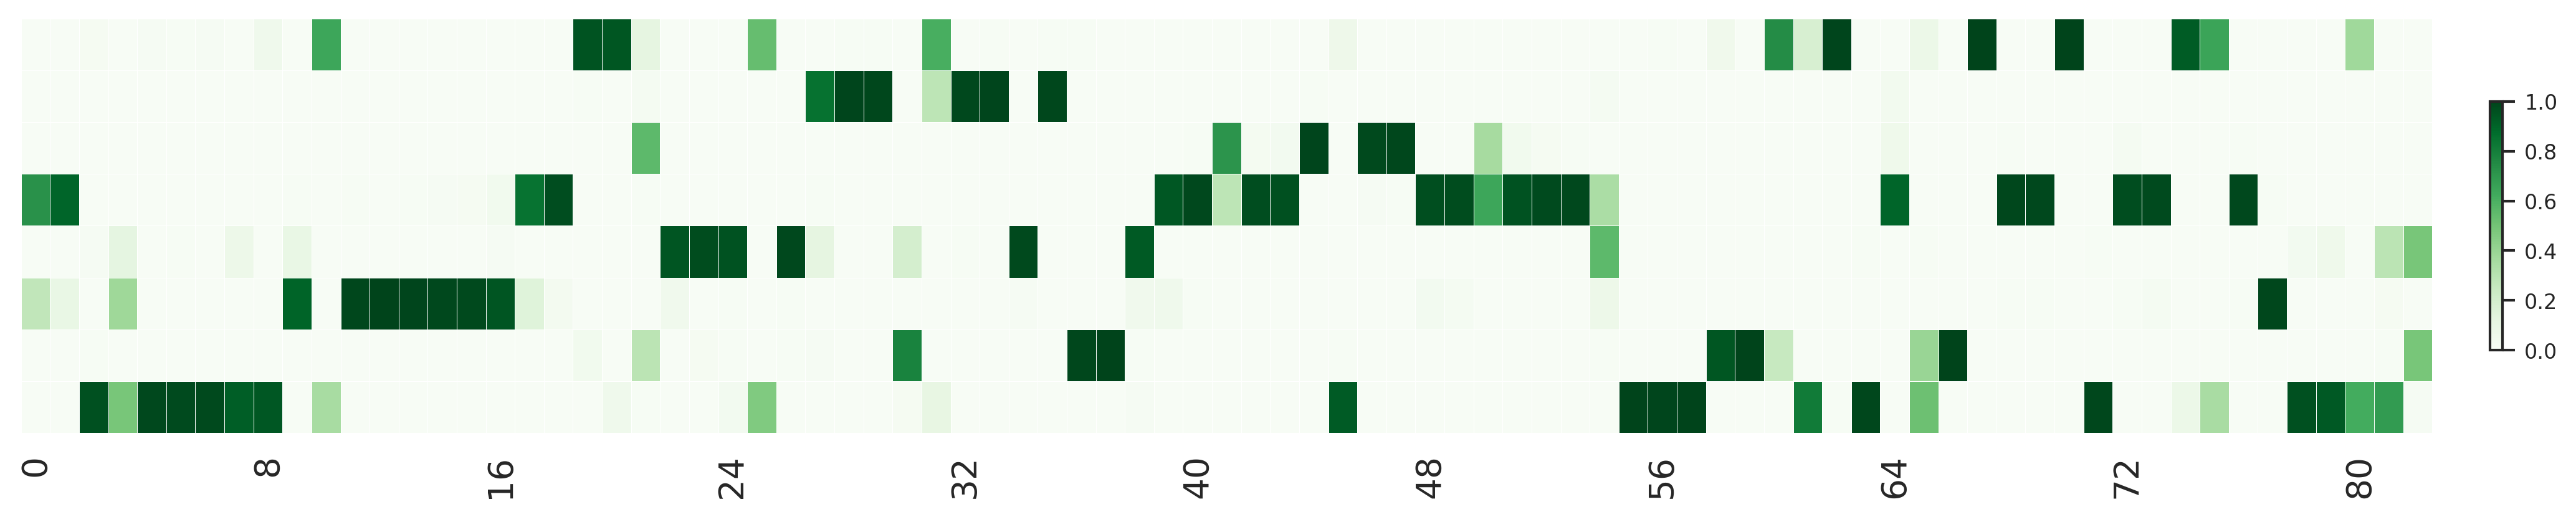

In [318]:
# --- 使用示例 ---
# 假设 plot_data, image_labels, text_labels 已定义
plot_data = torch.softmax(similarity_matrix_raw, dim=1).cpu().detach().numpy().transpose(1,0)
# plot_data = (plot_data-plot_data.min()) / (plot_data.max()-plot_data.min())
image_labels, text_labels = None, None #anatomy
plot_wide_attention_heatmap(plot_data, image_labels, text_labels, cmap_name='Greens')


In [292]:
def plot_wide_attention_heatmap(data, x_labels=None, y_labels=None, 
                                title="Cross-Modal Attention Map", 
                                cmap_name='icefire',
                                highlight_max=True,  # 新增：是否高亮最大值
                                highlight_color='red',  # 新增：高亮颜色
                                highlight_linewidth=2.5,  # 新增：高亮线宽
                                save_path=None):
    """
    专为宽矩阵 (如 8x80) 优化的学术级热力图 - 带最大值高亮
    """
    # 1. 基础设置
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5)
    
    rows, cols = data.shape
    
    # 2. 智能画布尺寸 (针对 8x80 优化)
    # cell_aspect = rows/cols
    # fig_w = min(14, cols * 0.15)
    # fig_h = max(rows * 0.8 + 2, 5)  # 确保最小高度
    fig_w,fig_h = 16, 3
    print(fig_w,fig_h)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)

    # 3. 高级配色方案
    if cmap_name == 'mako':
        cmap = sns.color_palette("mako", as_cmap=True)
    elif cmap_name == 'flare':
        cmap = sns.color_palette("flare", as_cmap=True)
    elif cmap_name == 'custom_premium':
        colors = ["#2D004E", "#5E2D79", "#964F9C", "#C97FB6", "#F9B5D2", "#FFD966"]
        cmap = mcolors.LinearSegmentedColormap.from_list("custom_premium", colors, N=100)
    else:
        cmap = sns.color_palette(cmap_name, as_cmap=True)

    # 4. 绘制热力图
    g = sns.heatmap(data, 
                    ax=ax,
                    annot=False,
                    fmt=".2f",
                    cmap=cmap, 
                    cbar_kws={'shrink': 0.6, 'pad': 0.02},
                    linewidths=0.2,
                    linecolor='white',
                    xticklabels=True, 
                    yticklabels=False,
                    vmin=0, vmax=1,
                    rasterized=True
                    )

    # 5. 刻度采样优化
    step = max(1, cols // 10)
    x_ticks = np.arange(0, cols, step)
    ax.set_xticks(x_ticks + 0.5)
    ax.set_xticklabels([str(i) for i in x_ticks], rotation=45, ha='right', fontsize=10)
    
    # 6. ✨ 最大值高亮标记 (Max Value Highlighting)
    if highlight_max:
        for row_idx in range(rows):
            # 找到每行最大值的列索引
            col_idx = np.argmax(data[row_idx, :])
            max_value = data[row_idx, col_idx]
            
            # 绘制矩形框 (Rectangle Patch)
            # 注意：heatmap 的坐标从 0 开始，矩形位置需要对应单元格
            rect = plt.Rectangle(
                (col_idx, row_idx),      # 左下角坐标 (x, y)
                1, 1,                     # 宽度和高度
                fill=False,               # 不填充，只画边框
                edgecolor=highlight_color,  # 边框颜色
                linewidth=highlight_linewidth,  # 边框宽度
                linestyle='-',            # 实线
                zorder=10                 # 确保在最上层
            )
            ax.add_patch(rect)
            
            # 可选：在最大值单元格内添加星号标记
            # ax.text(col_idx + 0.5, row_idx + 0.5, '★', 
            #         color=highlight_color, fontsize=16, 
            #         ha='center', va='center', fontweight='bold', zorder=11)

    # 7. 美学微调
    # ax.set_title(title, fontsize=16, fontweight='bold', pad=15, fontname='DejaVu Sans')
    # ax.set_xlabel("Image Patches / Tokens", fontsize=12, labelpad=10)
    
    # 移除多余脊线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # Colorbar 美化
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_linewidth(1)
    cbar.set_label('Attention Score', fontsize=10, labelpad=5)
    
    # 8. 布局与保存
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Saved to {save_path}")
    plt.show()
    plt.close()


In [ ]:
# --- 使用示例 ---
# 假设 plot_data, image_labels, text_labels 已定义
plot_data = torch.softmax(similarity_matrix_raw, dim=1).cpu().detach().numpy().transpose(1,0)
# plot_data = (plot_data-plot_data.min()) / (plot_data.max()-plot_data.min())
image_labels, text_labels = None, None #anatomy
plot_wide_attention_heatmap(plot_data, image_labels, text_labels, cmap_name='mako')
